# Experiment 6 — Intraday event study: is there tradeable post-news drift? (2024)

Experiments 1–5 used **daily** bars: sentiment correlates with price the *same day*
(FinBERT r≈0.23) but has **zero forward** power. The likely reason: the signal is
absorbed **intraday**. Here we test that directly with **minute bars + timestamped
Benzinga news** (via Alpaca), for **2024 only**.

**Hypothesis:** after a TSLA headline publishes at time *t*, price keeps **drifting**
in the sentiment direction over the next minutes — enough to trade *after* the first
print (not fully absorbed instantly).

We separate:
- **reaction** = move in the first minute `[t, t+1m]` — untradeable (you can't beat the first print),
- **drift** = move over `[t+1m, t+Δ]` — the tradeable part.

In [1]:
# 1. Setup
import html
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch
from scipy import stats
from transformers import AutoTokenizer, AutoModelForSequenceClassification

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "experiment_6" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
import get_bars as gb  # reuse auth headers + paginated bar generator

MODEL_NAME = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).eval()
device = "mps" if torch.backends.mps.is_available() else "cpu"
model.to(device)
lbl = {v.lower(): k for k, v in model.config.id2label.items()}
POS, NEG = lbl["positive"], lbl["negative"]

START, END = "2024-01-01T00:00:00Z", "2025-01-01T00:00:00Z"
ET = "America/New_York"
print("Device:", device)

/Users/georgia/Documents/Trading/sentimental_trading/trade_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 28711.48it/s]

Device: mps


## 2. Fetch all 2024 TSLA news (Benzinga, timestamped)

In [2]:
# 2. Paginated news pull via Alpaca REST /v1beta1/news
NEWS_URL = "https://data.alpaca.markets/v1beta1/news"

def get_all_news(symbol, start, end):
    params = {"symbols": symbol, "start": start, "end": end, "limit": 50,
              "sort": "asc", "exclude_contentless": "true"}
    items, pages = [], 0
    while True:
        r = requests.get(NEWS_URL, headers=gb.HEADERS, params=params, timeout=30)
        r.raise_for_status()
        j = r.json()
        items.extend(j.get("news", []))
        pages += 1
        tok = j.get("next_page_token")
        if not tok:
            break
        params["page_token"] = tok
    print(f"  {pages} pages, {len(items)} items")
    return items

raw = get_all_news("TSLA", START, END)
news = pd.DataFrame([{
    "t_utc": it["created_at"],
    "headline": it.get("headline", "") or "",
    "summary": html.unescape(it.get("summary", "") or ""),
} for it in raw])
news["t"] = pd.to_datetime(news["t_utc"], utc=True).dt.tz_convert(ET).dt.tz_localize(None)
news = news.sort_values("t").reset_index(drop=True)
print(f"{len(news)} TSLA news items in 2024 | {news['t'].min()} -> {news['t'].max()} (ET)")
news.head(3)

  85 pages, 4209 items
4209 TSLA news items in 2024 | 2021-03-19 03:16:36 -> 2024-12-31 12:35:16 (ET)


,t_utc,headline,summary,t
0,2021-03-19T07:16:36Z,NFT Craze A Reminder Of Tulip Mania? Keep Calm...,The non-fungible tokens are mirroring a period...,2021-03-19 03:16:36
1,2021-04-08T14:02:55Z,"Facebook Beta Tests Hotline, Its Answer To Clu...","Facebook, Inc. (NASDAQ: FB) is beta testing Ho...",2021-04-08 10:02:55
2,2021-06-25T16:30:26Z,Did Billionaire Elon Musk Sell All His Mansion...,Despite a wealth of $162.8 billion and title o...,2021-06-25 12:30:26


## 3. Score sentiment with FinBERT (headline + summary)

In [3]:
# 3. FinBERT signed score on headline + summary
@torch.no_grad()
def finbert_scores(texts, batch_size=32, max_length=512):
    out = []
    n = len(texts)
    for i in range(0, n, batch_size):
        batch = [t if isinstance(t, str) and t.strip() else "neutral" for t in texts[i:i + batch_size]]
        enc = tokenizer(batch, return_tensors="pt", truncation=True,
                        max_length=max_length, padding=True).to(device)
        probs = torch.softmax(model(**enc).logits, dim=-1)
        out.extend((probs[:, POS] - probs[:, NEG]).cpu().numpy().tolist())
        if (i // batch_size) % 20 == 0:
            print(f"  {min(i + batch_size, n):,}/{n:,}", end="\r")
    return out

text = (news["headline"] + ". " + news["summary"]).str.strip()
news["sentiment"] = finbert_scores(text.tolist())
print("\nsentiment range:", round(news["sentiment"].min(), 3), "to", round(news["sentiment"].max(), 3),
      "| positive:", int((news["sentiment"] > 0).sum()), "negative:", int((news["sentiment"] < 0).sum()))


sentiment range: -0.969 to 0.942 | positive: 2268 negative: 1941


## 4. Fetch 2024 minute bars & align timestamps to Eastern time

In [4]:
# 4. 1-minute TSLA bars (SIP -> IEX), converted to tz-naive ET
def fetch_min(feed):
    return list(gb.get_bars({"timeframe": "1Min", "start": START, "end": END, "limit": 10000,
                             "adjustment": "raw", "feed": feed, "sort": "asc"}))
try:
    mbars = fetch_min("sip"); feed_used = "sip"
except Exception as e:
    print("SIP failed -> IEX:", repr(e)[:70]); mbars = fetch_min("iex"); feed_used = "iex"

px = pd.DataFrame(mbars)[["t", "c"]]
px["t"] = pd.to_datetime(px["t"], utc=True).dt.tz_convert(ET).dt.tz_localize(None)
px = px.sort_values("t").reset_index(drop=True)
print(f"{len(px):,} minute bars via {feed_used}: {px['t'].min()} -> {px['t'].max()} (ET)")

229,081 minute bars via sip: 2024-01-02 04:00:00 -> 2024-12-31 19:00:00 (ET)


## 5. Align events to bars; compute reaction & drift returns

In [5]:
# 5a. Price-lookup helper: first bar at/after each target time (merge_asof forward)
pxk = px.rename(columns={"t": "key", "c": "px"})

def price_at(target_times, tol):
    left = pd.DataFrame({"key": pd.to_datetime(target_times).values})  # already sorted (monotonic shift of sorted t)
    m = pd.merge_asof(left, pxk, on="key", direction="forward", tolerance=pd.Timedelta(tol))
    return m["px"].values

# entry = first bar at/after publish; generous tol so every event gets next available liquidity
news = news.sort_values("t").reset_index(drop=True)
news["entry_px"] = price_at(news["t"], tol="12h")

# session bucket from publish-time ET clock
et_min = news["t"].dt.hour * 60 + news["t"].dt.minute
news["session"] = np.select(
    [et_min < 9 * 60 + 30, et_min < 16 * 60],
    ["pre-market", "regular"], default="after-hours")

# price 1 minute after publish (drift base) and at each horizon
news["px_1m"] = price_at(news["t"] + pd.Timedelta("1min"), tol="5min")
HZ = [5, 15, 30, 60]
for h in HZ:
    news[f"px_{h}m"] = price_at(news["t"] + pd.Timedelta(f"{h}min"), tol="10min")

# returns
news["reaction"] = news["px_1m"] / news["entry_px"] - 1
for h in HZ:
    news[f"drift_{h}m"] = news[f"px_{h}m"] / news["px_1m"] - 1      # tradeable: enter after 1st print
    news[f"total_{h}m"] = news[f"px_{h}m"] / news["entry_px"] - 1   # reaction + drift
print("session counts:\n", news["session"].value_counts())
print("\nnon-NaN drift_30m:", int(news["drift_30m"].notna().sum()), "/", len(news))
news.to_csv("tsla_2024_events.csv", index=False)
news[["t", "session", "sentiment", "reaction", "drift_30m", "total_30m"]].head()

session counts:
 session
pre-market     1749
regular        1641
after-hours     819
Name: count, dtype: int64

non-NaN drift_30m: 2736 / 4209


,t,session,sentiment,reaction,drift_30m,total_30m
0,2021-03-19 03:16:36,pre-market,-0.005071,NaN,NaN,NaN
1,2021-04-08 10:02:55,regular,0.268224,NaN,NaN,NaN
2,2021-06-25 12:30:26,regular,-0.571827,NaN,NaN,NaN
3,2021-09-20 11:52:05,regular,-0.951695,NaN,NaN,NaN
4,2021-11-02 16:43:25,after-hours,0.833940,NaN,NaN,NaN


## 6. Reaction vs. drift metrics

For each horizon: **IC** = correlation of sentiment with the *drift* return (the
tradeable part), the **long/short spread** (mean drift of positive- minus negative-
sentiment events), and the directional **hit rate**. Shown for all events and for
**regular-hours only** (cleanest). We also show the IC of the *reaction* to see how
much is absorbed instantly.

In [6]:
# 6. Metrics
def block(d, col):
    m = d["sentiment"].notna() & d[col].notna() & (d["sentiment"] != 0)
    x, y = d.loc[m, "sentiment"], d.loc[m, col]
    if m.sum() < 20:
        return dict(n=int(m.sum()), ic=np.nan, ic_p=np.nan, ls_spread=np.nan, hit=np.nan)
    ic, icp = stats.spearmanr(x, y)
    pos, neg = y[x > 0], y[x < 0]
    return dict(n=int(m.sum()), ic=round(ic, 4), ic_p=round(icp, 4),
                ls_spread=round(pos.mean() - neg.mean(), 6),
                hit=round(float((np.sign(x) == np.sign(y)).mean()), 4))

def metrics_for(d, label):
    rows = [{"scope": label, "window": "reaction [t,t+1m]", **block(d, "reaction")}]
    for h in HZ:
        rows.append({"scope": label, "window": f"drift [1m,{h}m]", **block(d, f"drift_{h}m")})
    return rows

reg = news[news["session"] == "regular"]
metrics = pd.DataFrame(metrics_for(news, "all events") + metrics_for(reg, "regular-hours"))
metrics.to_csv("tsla_2024_drift_metrics.csv", index=False)
metrics

,scope,window,n,ic,ic_p,ls_spread,hit
0,all events,"reaction [t,t+1m]",2742,-0.0194,0.3096,-0.000079,0.4661
1,all events,"drift [1m,5m]",2741,-0.0026,0.8914,-0.000032,0.4870
2,all events,"drift [1m,15m]",2741,0.0120,0.5302,-0.000064,0.5038
3,all events,"drift [1m,30m]",2736,0.0345,0.0709,0.000037,0.5004
4,all events,"drift [1m,60m]",2720,0.0320,0.0956,0.000246,0.5074
5,regular-hours,"reaction [t,t+1m]",1495,-0.0370,0.1525,-0.000162,0.4910
6,regular-hours,"drift [1m,5m]",1495,-0.0005,0.9849,0.000024,0.4983
7,regular-hours,"drift [1m,15m]",1495,0.0055,0.8304,-0.000068,0.5157
8,regular-hours,"drift [1m,30m]",1495,0.0264,0.3068,-0.000053,0.5057
9,regular-hours,"drift [1m,60m]",1495,0.0027,0.9169,0.000032,0.4997


## 7. Event-study CAR plot (regular-hours events)

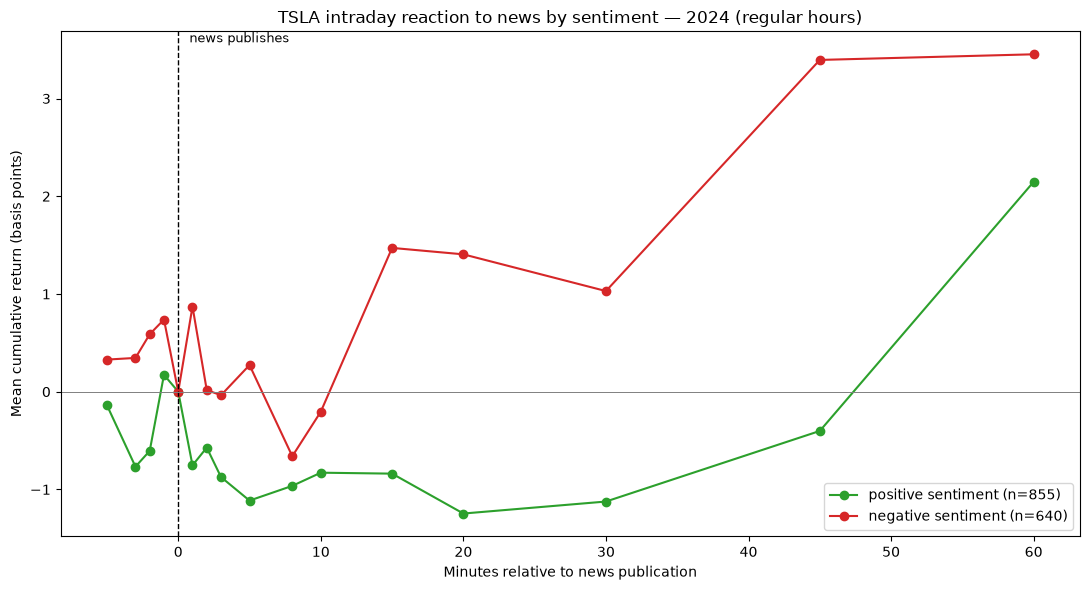

In [7]:
# 7. Mean cumulative return path around news, positive vs negative sentiment
offsets = [-5, -3, -2, -1, 0, 1, 2, 3, 5, 8, 10, 15, 20, 30, 45, 60]
ev = news[(news["session"] == "regular") & news["entry_px"].notna() & (news["sentiment"] != 0)].copy()
ev = ev.sort_values("t").reset_index(drop=True)
base = ev["entry_px"].values

paths = {}
for m in offsets:
    p = price_at(ev["t"] + pd.Timedelta(f"{m}min"), tol="3min")
    paths[m] = p / base - 1

car = pd.DataFrame(paths, index=ev.index)
pos_mask, neg_mask = ev["sentiment"] > 0, ev["sentiment"] < 0

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(offsets, [car.loc[pos_mask, m].mean() * 1e4 for m in offsets], "-o",
        color="tab:green", label=f"positive sentiment (n={int(pos_mask.sum())})")
ax.plot(offsets, [car.loc[neg_mask, m].mean() * 1e4 for m in offsets], "-o",
        color="tab:red", label=f"negative sentiment (n={int(neg_mask.sum())})")
ax.axvline(0, color="black", lw=1, ls="--")
ax.axhline(0, color="gray", lw=0.7)
ax.text(0.5, ax.get_ylim()[1], " news publishes", color="black", fontsize=9, va="top")
ax.set_xlabel("Minutes relative to news publication")
ax.set_ylabel("Mean cumulative return (basis points)")
ax.set_title("TSLA intraday reaction to news by sentiment — 2024 (regular hours)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Verdict

In [8]:
# 8. Is there tradeable drift?
def get(scope, window):
    r = metrics[(metrics["scope"] == scope) & (metrics["window"] == window)]
    return r.iloc[0] if len(r) else None

react = get("regular-hours", "reaction [t,t+1m]")
d30 = get("regular-hours", "drift [1m,30m]")

print("HYPOTHESIS: tradeable post-news drift exists (move not fully absorbed at first print)")
print("=" * 78)
print(f"Regular-hours reaction [t,t+1m]:  IC={react['ic']:+.3f} (p={react['ic_p']}), "
      f"L/S spread={react['ls_spread']*1e4:+.1f} bps  <- immediate, untradeable")
for h in HZ:
    d = get("regular-hours", f"drift [1m,{h}m]")
    tag = "  <- tradeable" if h == 30 else ""
    print(f"Regular-hours drift  [1m,{h:>2}m]:  IC={d['ic']:+.3f} (p={d['ic_p']}), "
          f"L/S spread={d['ls_spread']*1e4:+.1f} bps, hit={d['hit']:.3f}{tag}")

# absorption: how much of the 30m total move happens in the first minute?
mt = news["session"].eq("regular")
tot = news.loc[mt, "total_30m"].abs().mean()
rea = news.loc[mt, "reaction"].abs().mean()
print(f"\nAbsorption: mean |first-minute reaction| = {rea*1e4:.1f} bps of "
      f"mean |30m total move| = {tot*1e4:.1f} bps  ({rea/tot:.0%} in first minute)")

sig = (d30["ic_p"] < 0.05) and (d30["ic"] > 0)
verdict = ("SUPPORTED — significant positive post-news drift over 30m (before costs)"
           if sig else
           "NOT SUPPORTED — no significant tradeable drift; move absorbed at/near the first print")
print("\n" + "=" * 78 + f"\nVERDICT: {verdict}")
print("(Gross returns, no spread/fees — any bps edge must clear TSLA's bid-ask + costs.)")
print("Saved -> tsla_2024_events.csv, tsla_2024_drift_metrics.csv")

HYPOTHESIS: tradeable post-news drift exists (move not fully absorbed at first print)
Regular-hours reaction [t,t+1m]:  IC=-0.037 (p=0.1525), L/S spread=-1.6 bps  <- immediate, untradeable
Regular-hours drift  , 5m]:  IC=-0.001 (p=0.9849), L/S spread=+0.2 bps, hit=0.498
Regular-hours drift  ,15m]:  IC=+0.005 (p=0.8304), L/S spread=-0.7 bps, hit=0.516
Regular-hours drift  ,30m]:  IC=+0.026 (p=0.3068), L/S spread=-0.5 bps, hit=0.506  <- tradeable
Regular-hours drift  ,60m]:  IC=+0.003 (p=0.9169), L/S spread=+0.3 bps, hit=0.500

Absorption: mean |first-minute reaction| = 9.0 bps of mean |30m total move| = 47.8 bps  (19% in first minute)

VERDICT: NOT SUPPORTED — no significant tradeable drift; move absorbed at/near the first print
(Gross returns, no spread/fees — any bps edge must clear TSLA's bid-ask + costs.)
Saved -> tsla_2024_events.csv, tsla_2024_drift_metrics.csv


### Reading this

- The **CAR plot** is the key: if the green (positive) and red (negative) lines **jump
  at t=0 and then stay flat**, the news is absorbed in the first print → no drift → not
  tradeable. If they **keep separating after t=0**, that post-publication drift is the edge.
- **Reaction IC ≫ drift IC** is the efficient-market signature: information is in the price
  by the first minute.
- Even a positive drift IC only matters if the **L/S spread (bps)** exceeds TSLA's
  round-trip cost (spread + fees). This is a gross, no-cost study — treat a small positive
  drift as "worth a costed backtest," not as proven alpha.